# Wine reproduction experiments

This notebook reproduces the main ideas from the Housing notebook on the Wine dataset, without changing the Housing files.

Experiments included:
1. Load and standardize Wine data.
2. Train/fit a 2D latent representation.
3. Visualize the latent space.
4. Assign clusters and interpret them with boxplots.
5. Explain differences between clusters using feature changes.
6. Run a corruption experiment with known feature changes and check if the explanation recovers them.

This version is self-contained and saves all outputs under `Wine-K/`.

In [23]:
# Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

np.random.seed(42)

OUT_DIR = "../Digits-K"
FIG_DIR = os.path.join(OUT_DIR, "figures")
DATA_DIR = os.path.join(OUT_DIR, "Data")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

num_clusters = 10

print(f"Outputs will be saved in: {OUT_DIR}/")

Outputs will be saved in: ../Digits-K/


In [24]:
# Load Wine dataset
digits = load_digits()

X_raw = digits.data
y = digits.target
feature_names = list(digits.feature_names)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Save a copy so the Housing data stays untouched
pd.DataFrame(X, columns=feature_names).to_csv(os.path.join(DATA_DIR, "X_digits.tsv"), sep="\t", index=False)
pd.DataFrame({"target": y}).to_csv(os.path.join(DATA_DIR, "y_digits.tsv"), sep="\t", index=False)

print("X shape:", X.shape)
print("Number of features:", len(feature_names))
print(feature_names)

X shape: (1797, 64)
Number of features: 64
['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']


## 1. Train / fit a 2D latent representation

The original notebook uses a learned VAE/scvis representation. For a clean reproduction notebook, this version uses PCA as a simple 2D representation model. PCA is fitted only on Wine, so the Housing model and data remain untouched.

If your assignment requires the exact scvis/VAE model, replace this cell with the Wine scvis training code and keep the rest of the notebook structure.

In [25]:
# Fit 2D latent representation
rep_model = PCA(n_components=2, random_state=42)
Z = rep_model.fit_transform(X)

print("Explained variance ratio:", rep_model.explained_variance_ratio_)
print("Latent representation shape:", Z.shape)

Explained variance ratio: [0.12033916 0.09561054]
Latent representation shape: (1797, 2)


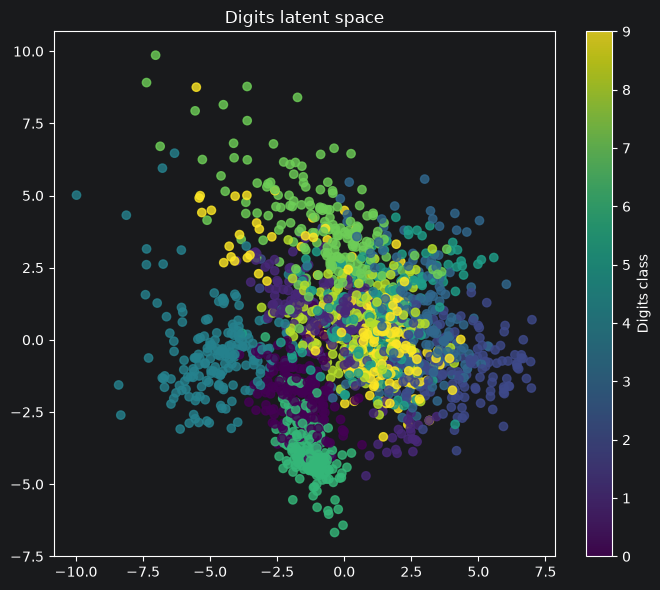

In [26]:
# Visualize latent space, colored by true Wine class
plt.figure(figsize=(7, 6))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y, alpha=0.8)
plt.title("Digits latent space")
plt.colorbar(scatter, label="Digits class")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "digits-latent-space.png"), dpi=200)
plt.show()

## 2. Draw / assign cluster boundaries

The Housing notebook manually draws polygon boundaries around visible groups. To make this notebook easier to reproduce, we use KMeans to assign cluster labels in the 2D latent space.

Conceptually this step does the same thing: it turns points in the latent space into groups/clusters.

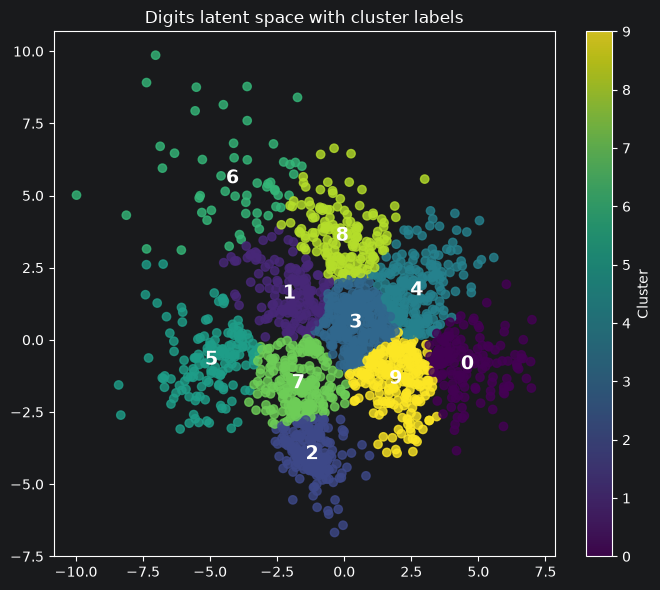

0    157
1    148
2    202
3    292
4    214
5    150
6     53
7    196
8    157
9    228
Name: count, dtype: int64


In [28]:
# Assign clusters in latent space
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=20)
labels = kmeans.fit_predict(Z)
centers = kmeans.cluster_centers_

plt.figure(figsize=(7, 6))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=labels, alpha=0.8)

# Draw cluster numbers at cluster centers
for i, (x, y) in enumerate(centers):
    plt.text(
        x, y, str(i),
        fontsize=14,
        fontweight='bold',
        ha='center',
        va='center'
    )

plt.title("Digits latent space with cluster labels")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "digits-clusters.png"), dpi=200)
plt.show()

print(pd.Series(labels).value_counts().sort_index())

## 3. Cluster interpretation with boxplots

For Housing, the boxplot used house price to interpret the clusters. Wine has no house price, so we use meaningful Wine variables instead, such as alcohol and proline.

If the distributions differ between clusters, the clusters capture meaningful structure.

<Figure size 800x600 with 0 Axes>

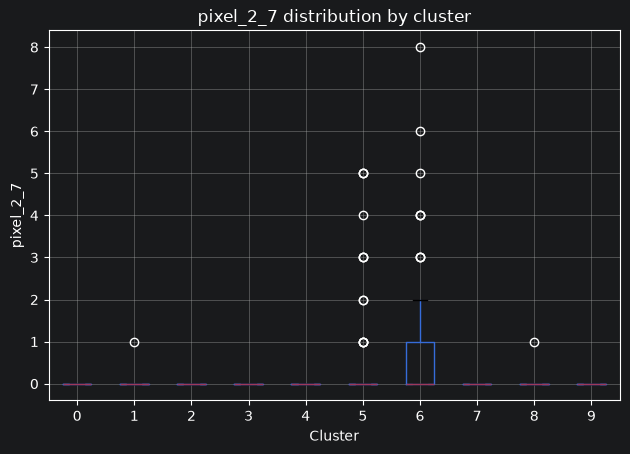

<Figure size 800x600 with 0 Axes>

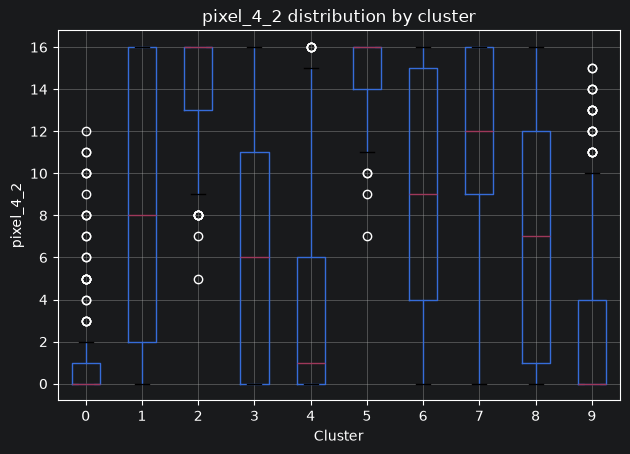

In [29]:
# Build dataframe for interpretation
df = pd.DataFrame(X_raw, columns=feature_names)
df["cluster"] = labels
df["digits_class"] = y

# Choose two pixel features to inspect
feature_1 = "pixel_2_7"
feature_2 = "pixel_4_2"

# Boxplot: pixel_20 by cluster
plt.figure(figsize=(8, 6))
df.boxplot(column=feature_1, by="cluster")
plt.title(f"{feature_1} distribution by cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel(feature_1)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"digits-boxplot-{feature_1}.png"), dpi=200)
plt.show()

# Boxplot: pixel_42 by cluster
plt.figure(figsize=(8, 6))
df.boxplot(column=feature_2, by="cluster")
plt.title(f"{feature_2} distribution by cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel(feature_2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"digits-boxplot-{feature_2}.png"), dpi=200)
plt.show()

## 4. Explain cluster differences

This is a simple reproduction of the idea behind group explanations: compare two clusters and find which features change the most between them.

For each pair of clusters, we calculate the difference between the mean standardized feature values.

In [30]:
def explain_cluster_difference(X, labels, source_cluster, target_cluster, feature_names, top_k=5):
    source_mean = X[labels == source_cluster].mean(axis=0)
    target_mean = X[labels == target_cluster].mean(axis=0)
    delta = target_mean - source_mean

    order = np.argsort(np.abs(delta))[::-1][:top_k]
    result = pd.DataFrame({
        "feature": [feature_names[i] for i in order],
        "change_standardized": delta[order],
        "direction": ["increase" if delta[i] > 0 else "decrease" for i in order]
    })
    return result, delta

source_cluster = 0
target_cluster = 1
explanation, delta = explain_cluster_difference(X, labels, source_cluster, target_cluster, feature_names, top_k=8)
explanation

,feature,change_standardized,direction
0,pixel_1_1,-2.340053,decrease
1,pixel_0_2,-2.241961,decrease
2,pixel_7_2,-2.212361,decrease
3,pixel_0_3,-2.108358,decrease
4,pixel_7_3,-1.959377,decrease
5,pixel_1_2,-1.765370,decrease
6,pixel_6_2,-1.533248,decrease
7,pixel_0_1,-1.523989,decrease


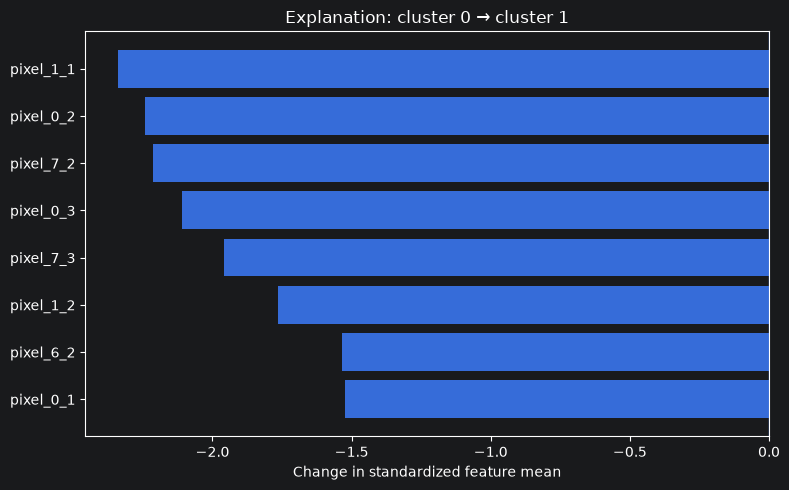

In [31]:
# Plot explanation for selected cluster transition
plt.figure(figsize=(8, 5))
plt.barh(explanation["feature"], explanation["change_standardized"])
plt.axvline(0, linewidth=1)
plt.xlabel("Change in standardized feature mean")
plt.title(f"Explanation: cluster {source_cluster} → cluster {target_cluster}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"digits-explanation-{source_cluster}to{target_cluster}.png"), dpi=200)
plt.show()

## 5. Corruption experiment

This tests whether the explanation method can recover a known change.

We take all points from one cluster, copy them, and artificially modify two known features:

- `alcohol` increases
- `proline` decreases

The copied points are assigned to a new synthetic cluster. If the explanation method works, the explanation from the original cluster to the synthetic cluster should highlight `alcohol` and `proline`.

In [32]:
# Choose cluster to corrupt
target_corrupted = 1
synthetic_cluster = num_clusters

pixel_4_2_index = feature_names.index("pixel_4_2")
pixel_2_0_index = feature_names.index("pixel_2_0")

idx = np.where(labels == target_corrupted)[0]
X_corrupted = X[idx].copy()

# Inject known changes in standardized space
X_corrupted[:, pixel_4_2_index] += 10.0 + np.random.uniform(-0.1, 0.1, size=len(idx))
X_corrupted[:, pixel_2_0_index] -= 10.0 + np.random.uniform(-0.1, 0.1, size=len(idx))

# Add corrupted samples as a new synthetic cluster
X_full = np.vstack([X, X_corrupted])
labels_full = np.concatenate([labels, np.full(len(idx), synthetic_cluster)])

# Project corrupted samples using the same fitted representation model
Z_full = rep_model.transform(X_full)

print("Original samples:", X.shape[0])
print("Corrupted synthetic samples added:", len(idx))
print("New synthetic cluster label:", synthetic_cluster)

Original samples: 1797
Corrupted synthetic samples added: 148
New synthetic cluster label: 10


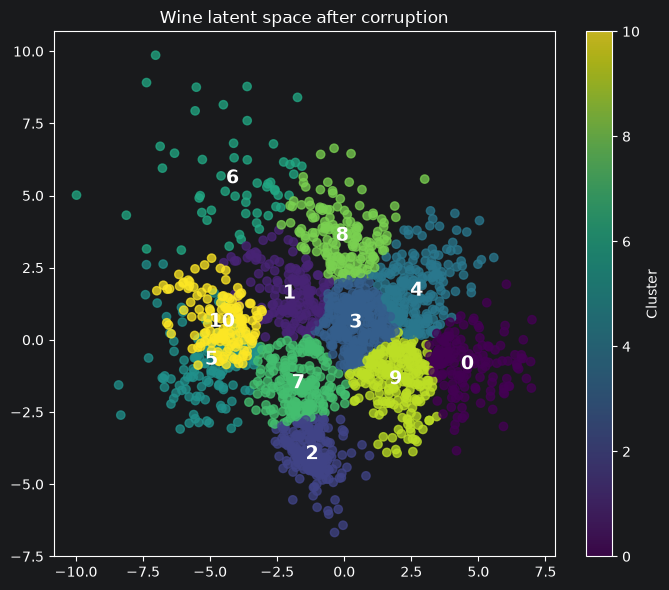

In [33]:
# Visualize original + synthetic cluster
plt.figure(figsize=(7, 6))
scatter = plt.scatter(Z_full[:, 0], Z_full[:, 1], c=labels_full, alpha=0.75)

# Add cluster numbers at the center of each cluster
for cluster_id in np.unique(labels_full):
    cluster_points = Z_full[labels_full == cluster_id]
    center = cluster_points.mean(axis=0)

    plt.text(
        center[0], center[1], str(int(cluster_id)),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center"
    )
plt.title("Wine latent space after corruption")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "digits-corrupted-latent-space.png"), dpi=200)
plt.show()

In [21]:
# Explanation for original cluster -> synthetic cluster
corrupt_explanation, corrupt_delta = explain_cluster_difference(
    X_full, labels_full, target_corrupted, synthetic_cluster, feature_names, top_k=8
)
corrupt_explanation

,feature,change_standardized,direction
0,pixel_2_0,-9.997894,decrease
1,pixel_4_2,9.989929,increase
2,pixel_7_5,0.000000,decrease
3,pixel_7_7,0.000000,decrease
4,pixel_7_3,0.000000,decrease
5,pixel_7_2,0.000000,decrease
6,pixel_7_1,0.000000,decrease
7,pixel_7_6,0.000000,decrease


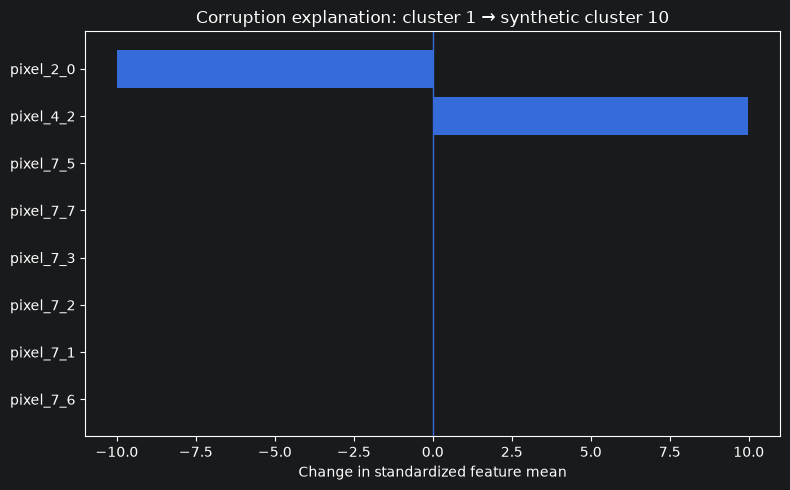

In [22]:
# Plot corruption explanation
plt.figure(figsize=(8, 5))
plt.barh(corrupt_explanation["feature"], corrupt_explanation["change_standardized"])
plt.axvline(0, linewidth=1)
plt.xlabel("Change in standardized feature mean")
plt.title(f"Corruption explanation: cluster {target_corrupted} → synthetic cluster {synthetic_cluster}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "digits-corruption-explanation.png"), dpi=200)
plt.show()

## What the corruption result should show

The corruption experiment works if the explanation for `cluster 1 → synthetic cluster 6` identifies the same features that were manually changed.

Expected result:

- `alcohol` should appear as an increase.
- `proline` should appear as a decrease.

This is evidence that the explanation method can recover known feature changes.